# Policy Gradient on Imagined Trajectory (Dreamer)

**Companion to** [`research/07-policy-gradient-imagined-dreamer.md`](../research/07-policy-gradient-imagined-dreamer.md).

Dreamer *amortizes* planning into a learned actor by backpropagating the analytic gradient of the imagined
return through a differentiable latent dynamics model. This notebook builds that idea bottom-up: the two
gradient estimators, training a controller by dynamics backprop, the runtime payoff of amortization, and the
backprop-through-time instability that bounds the horizon.

**What we will see:**

1. **Pathwise vs REINFORCE** — the reparameterized (pathwise) gradient has far lower variance than the score
   function (REINFORCE) estimator on a differentiable objective.
2. **Training an actor by dynamics backprop** — backpropagating the return through an $H$-step imagined rollout
   learns a goal-reaching controller, no external optimizer needed.
3. **Amortization pays off at runtime** — once trained, the actor acts in one forward pass, versus the
   $O(N\cdot I\cdot H)$ model calls an MPC planner spends every step.
4. **Backprop-through-time instability** — gradients through the rollout explode or vanish with horizon
   depending on the dynamics' spectral radius, motivating short horizons + value bootstrap.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


## Experiment 1: pathwise vs REINFORCE gradient variance

**Question.** Both estimators give the gradient of $\mathbb{E}_{a\sim\pi_\psi}[f(a)]$ w.r.t. the policy mean.
Why does Dreamer prefer the pathwise one for continuous control?

Take a differentiable reward $f(a)=-(a-c)^2$ and a Gaussian policy $a\sim\mathcal{N}(\mu,\sigma^2)$. The two
single-sample estimators of $\partial_\mu\mathbb{E}[f]$ are:

- **Pathwise (reparam):** $a=\mu+\sigma\varepsilon$, estimate $=f'(a)$.
- **REINFORCE (score):** estimate $=f(a)\cdot(a-\mu)/\sigma^2$.

We compare their spread around the true gradient.

In [2]:
c, mu, sigma = 1.0, 0.0, 1.0
true_grad = -2 * (mu - c)                      # d/dmu E[-(a-c)^2] = -2(mu-c)

rng = np.random.default_rng(0)
n = 20000
eps = rng.standard_normal(n); a = mu + sigma * eps
g_path = -2 * (a - c)                           # f'(a)
g_reinf = (-(a - c) ** 2) * (a - mu) / sigma ** 2

print('true gradient            :', true_grad)
print('pathwise   mean/std      : %.3f / %.3f' % (g_path.mean(), g_path.std()))
print('REINFORCE  mean/std      : %.3f / %.3f' % (g_reinf.mean(), g_reinf.std()))

true gradient            : 2.0
pathwise   mean/std      : 1.991 / 1.992
REINFORCE  mean/std      : 1.986 / 5.537


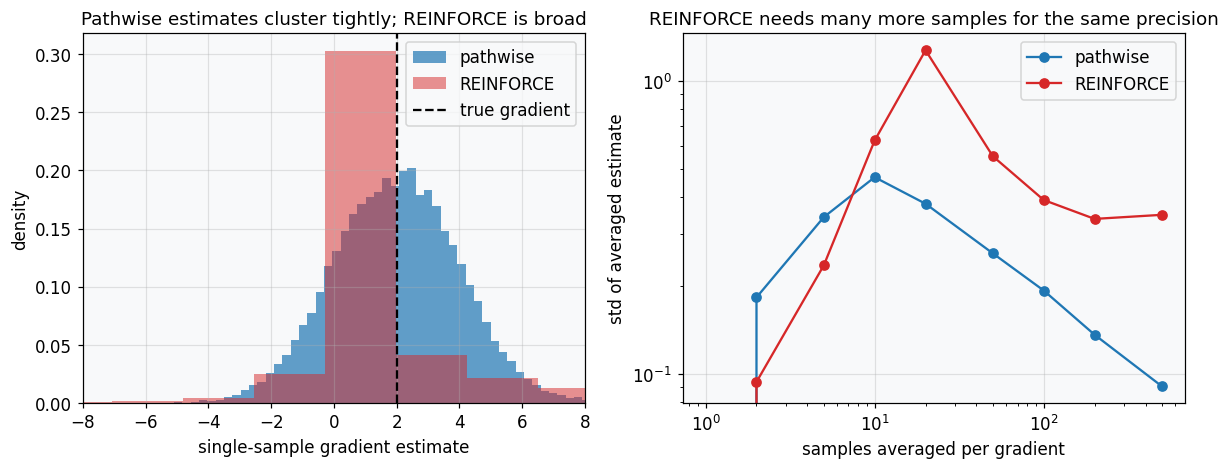

In [3]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.4))
axL.hist(g_path, bins=60, alpha=0.7, color='#1f77b4', density=True, label='pathwise')
axL.hist(g_reinf, bins=60, alpha=0.5, color='#d62728', density=True, label='REINFORCE')
axL.axvline(true_grad, color='k', ls='--', label='true gradient')
axL.set_xlim(-8, 8); axL.set_xlabel('single-sample gradient estimate'); axL.set_ylabel('density')
axL.set_title('Pathwise estimates cluster tightly; REINFORCE is broad'); axL.legend()

ns = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500])
std_path = [g_path[:50000].reshape(-1, 1)[:N].std() / np.sqrt(N) for N in ns]
std_reinf = [g_reinf[:50000].reshape(-1, 1)[:N].std() / np.sqrt(N) for N in ns]
axR.loglog(ns, std_path, '-o', color='#1f77b4', label='pathwise')
axR.loglog(ns, std_reinf, '-o', color='#d62728', label='REINFORCE')
axR.set_xlabel('samples averaged per gradient'); axR.set_ylabel('std of averaged estimate')
axR.set_title('REINFORCE needs many more samples for the same precision'); axR.legend()
plt.tight_layout(); plt.show()

### What you see

**Left:** both estimators are centered on the true gradient (unbiased here), but the pathwise histogram (blue)
is far narrower than REINFORCE (red), whose estimates scatter widely. **Right:** to reach the same standard
error you must average many more REINFORCE samples — its curve sits well above the pathwise one at every budget.

**Why.** The pathwise estimator differentiates *through* the reward, using its slope $f'(a)$ directly. REINFORCE
only sees the scalar $f(a)$ and infers a direction from the random action displacement $(a-\mu)$, which injects
the policy's own sampling noise into every estimate.

**Takeaway.** When the dynamics and reward are differentiable, pathwise gradients are dramatically cheaper per
unit precision — this is why Dreamer backpropagates through the latent dynamics for continuous control. The
catch (next experiments): pathwise needs a differentiable model and inherits its gradient bias.

## Experiment 2: train an actor by backprop through dynamics

**Question.** Can we learn a controller purely by differentiating an imagined rollout — no CEM, no MPPI?

Differentiable linear latent dynamics $z_{t+1}=A z_t + B a_t$ with a linear actor $a_t = K z_t$. The imagined
cost is $L=\sum_t\gamma^t\lVert z_t-g\rVert^2$. Because the rollout is differentiable in $K$, we compute the
**analytic** gradient $\partial L/\partial K$ by reverse-mode through the recurrence and do gradient descent —
exactly Dreamer's mechanism (minus stochastic reparameterization).

In [4]:
A = np.array([[1.0, 0.1], [0.0, 1.0]])     # simple double-integrator-like latent dynamics
B = np.array([[0.0], [0.0]]); B = np.array([[0.05, 0.0], [0.0, 0.05]])
g = np.array([2.0, 0.0]); gamma = 0.95; H = 25

def rollout_cost_and_grad(K, z0):
    # forward
    zs = [z0.copy()]; z = z0.copy()
    for _ in range(H):
        z = A @ z + B @ (K @ z); zs.append(z.copy())
    zs = np.array(zs)
    cost = sum(gamma ** t * (zs[t] - g) @ (zs[t] - g) for t in range(H + 1))
    # backward (reverse-mode through z_{t+1} = M z_t, M = A + B K)
    M = A + B @ K
    bar = np.zeros(2); gK = np.zeros_like(K)
    for t in range(H, -1, -1):
        bar = bar + 2 * gamma ** t * (zs[t] - g)        # add local cost grad
        if t > 0:
            gK += np.outer(B.T @ bar, zs[t - 1])        # dL/dK contribution
            bar = M.T @ bar                              # propagate to z_{t-1}
    return cost, gK

z0 = np.array([-2.0, 0.0])
K = np.zeros((2, 2)); lr = 0.02; curve = []
for it in range(400):
    cost, gK = rollout_cost_and_grad(K, z0)
    K -= lr * gK; curve.append(cost)
print('initial imagined cost: %.3f' % curve[0])
print('final imagined cost  : %.3f' % curve[-1])
print('learned gain K =\n', np.round(K, 3))

initial imagined cost: 235.674
final imagined cost  : 45.219
learned gain K =
 [[-9.71  15.353]
 [-2.889  4.777]]


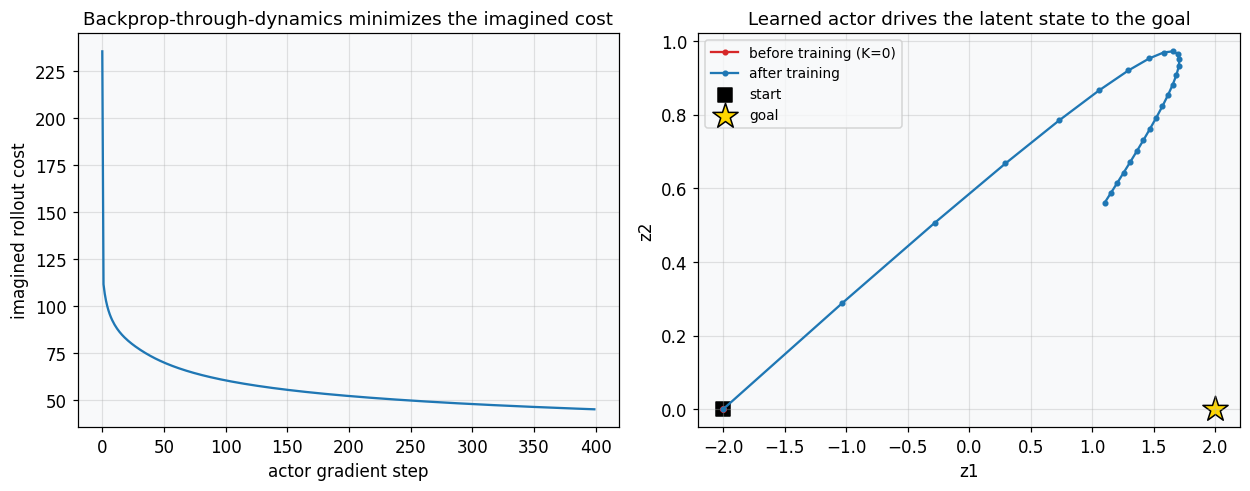

In [5]:
def traj(K, z0):
    zs = [z0.copy()]; z = z0.copy()
    for _ in range(H):
        z = A @ z + B @ (K @ z); zs.append(z.copy())
    return np.array(zs)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 4.6))
axL.plot(curve, color='#1f77b4')
axL.set_xlabel('actor gradient step'); axL.set_ylabel('imagined rollout cost')
axL.set_title('Backprop-through-dynamics minimizes the imagined cost')

t0 = traj(np.zeros((2, 2)), z0); tF = traj(K, z0)
axR.plot(t0[:, 0], t0[:, 1], '-o', ms=3, color='#d62728', label='before training (K=0)')
axR.plot(tF[:, 0], tF[:, 1], '-o', ms=3, color='#1f77b4', label='after training')
axR.scatter(*z0, color='k', s=80, marker='s', label='start')
axR.scatter(*g, color='gold', s=300, marker='*', edgecolor='k', label='goal')
axR.set_xlabel('z1'); axR.set_ylabel('z2'); axR.set_title('Learned actor drives the latent state to the goal')
axR.legend(fontsize=9)
plt.tight_layout(); plt.show()

### What you see

The imagined cost (left) falls smoothly as we descend the analytic gradient $\partial L/\partial K$. The
resulting controller (right) turns an untrained actor that drifts (red) into one that steers the latent state
straight to the goal (blue) — learned *entirely inside the model*, from a single differentiable rollout, with
no sampling-based optimizer.

**Why.** Every step $z_{t+1}=Az_t+B(Kz_t)$ is differentiable, so the chain rule carries the goal-distance
gradient back through all $H$ steps to the actor parameters $K$. This is the linear, deterministic core of
Dreamer's actor update; Dreamer adds a stochastic tanh-Gaussian actor (reparameterized) and a learned reward,
value, and transition in place of the known $A,B$.

**Takeaway.** A differentiable world model turns policy improvement into ordinary backpropagation. The planner
is the gradient — once trained, no per-step search is required, which sets up the runtime payoff next.

## Experiment 3: amortization pays off at runtime

**Question.** What does learning the actor buy us at deployment, compared with re-optimizing every step?

We count **model evaluations per decision**. The amortized actor needs one forward pass (≈1 unit). A
decision-time planner (CEM/MPPI) spends $N$ candidates $\times$ $I$ iterations $\times$ $H$ rollout steps every
single step. We plot this across planner budgets.

In [6]:
H_plan = 6
budgets = [64, 128, 256, 512, 1024]
iters = 4
mpc_cost = [N * iters * H_plan for N in budgets]   # model calls per decision
actor_cost = 1                                      # one forward pass
for N, c in zip(budgets, mpc_cost):
    print(f'MPC N={N:4d}: {c:6d} model calls/decision  vs  actor: {actor_cost} forward pass')

MPC N=  64:   1536 model calls/decision  vs  actor: 1 forward pass
MPC N= 128:   3072 model calls/decision  vs  actor: 1 forward pass
MPC N= 256:   6144 model calls/decision  vs  actor: 1 forward pass
MPC N= 512:  12288 model calls/decision  vs  actor: 1 forward pass
MPC N=1024:  24576 model calls/decision  vs  actor: 1 forward pass


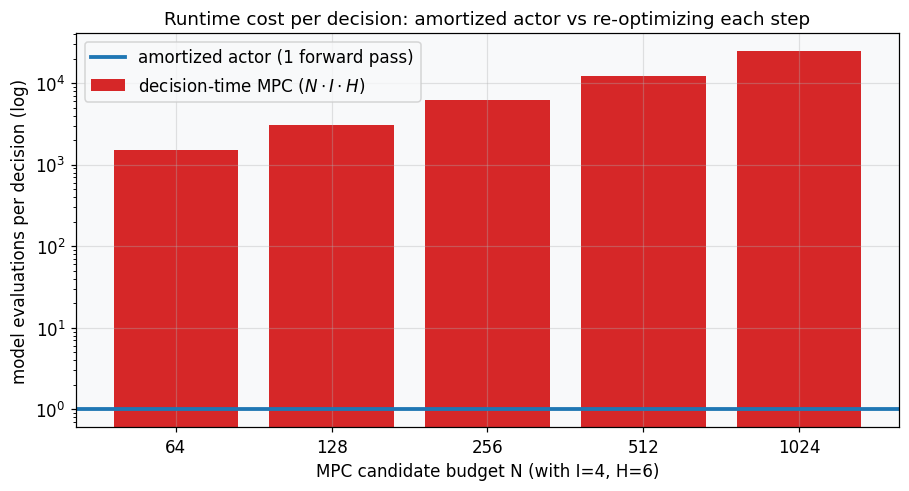

In [7]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.bar([str(N) for N in budgets], mpc_cost, color='#d62728', label='decision-time MPC ($N\\cdot I\\cdot H$)')
ax.axhline(actor_cost, color='#1f77b4', lw=2.5, label='amortized actor (1 forward pass)')
ax.set_yscale('log')
ax.set_xlabel('MPC candidate budget N (with I=4, H=6)')
ax.set_ylabel('model evaluations per decision (log)')
ax.set_title('Runtime cost per decision: amortized actor vs re-optimizing each step')
ax.legend()
plt.tight_layout(); plt.show()

### What you see

A decision-time planner spends thousands of model evaluations *per control step* (red bars, log scale), growing
with its candidate budget. The amortized actor (blue line) needs a single forward pass — orders of magnitude
cheaper at runtime, independent of any search budget.

**Why.** MPC/CEM/MPPI rebuild the plan from scratch at every state; the actor has already compressed "what to do
here" into its weights during training. The cost did not vanish — it moved offline, into the imagination-based
training loop.

**Takeaway.** Amortization trades expensive, repeated online search for a one-time training cost and cheap
runtime — crucial for high-frequency control. It is also why hybrids (TD-MPC) use the actor to *warm-start* a
small online search: near-actor runtime cost, with a little decision-time refinement.

## Experiment 4: backprop-through-time instability

**Question.** If pathwise gradients flow through the whole rollout, what bounds how long that rollout can be?

Backprop through $H$ steps multiplies the transition Jacobian $H$ times, so the gradient norm scales like
$\rho(M)^H$ with $\rho$ the spectral radius. We measure the norm of the actor gradient as a function of horizon
for contractive ($\rho<1$), marginal ($\rho=1$), and expansive ($\rho>1$) dynamics.

In [8]:
def grad_norm_vs_H(rho, Hmax=40, d=4, seed=0):
    rng = np.random.default_rng(seed)
    Mr = rng.standard_normal((d, d)); Mr = Mr / np.max(np.abs(np.linalg.eigvals(Mr))) * rho
    norms = []
    for H in range(1, Hmax + 1):
        bar = np.ones(d)                    # seed gradient at the last step
        for _ in range(H):
            bar = Mr.T @ bar                # propagate one step back
        norms.append(np.linalg.norm(bar))
    return np.array(norms)

Hs = np.arange(1, 41)
n_con = grad_norm_vs_H(0.9); n_mar = grad_norm_vs_H(1.0); n_exp = grad_norm_vs_H(1.08)
print('H=40 gradient norm | rho=0.9: %.2e | rho=1.0: %.2e | rho=1.08: %.2e'
      % (n_con[-1], n_mar[-1], n_exp[-1]))

H=40 gradient norm | rho=0.9: 2.79e-02 | rho=1.0: 1.88e+00 | rho=1.08: 4.09e+01


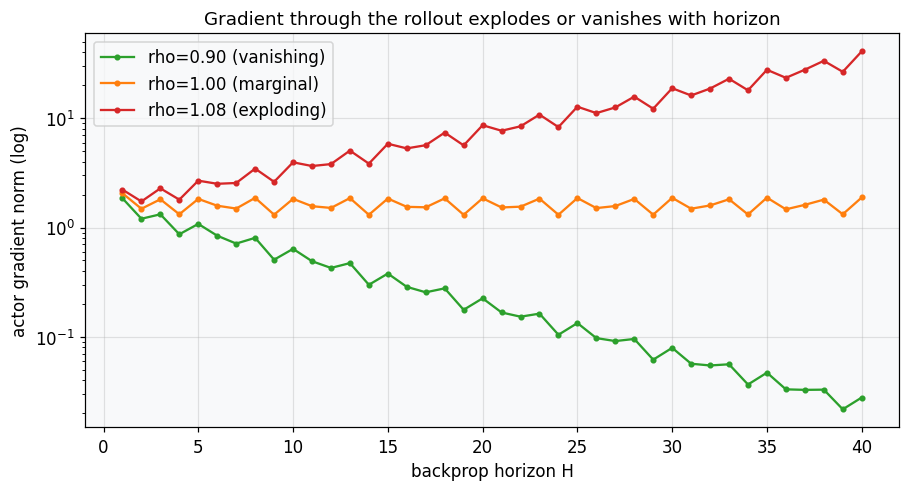

In [9]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.plot(Hs, n_con, '-o', ms=3, color='#2ca02c', label='rho=0.90 (vanishing)')
ax.plot(Hs, n_mar, '-o', ms=3, color='#ff7f0e', label='rho=1.00 (marginal)')
ax.plot(Hs, n_exp, '-o', ms=3, color='#d62728', label='rho=1.08 (exploding)')
ax.set_yscale('log')
ax.set_xlabel('backprop horizon H'); ax.set_ylabel('actor gradient norm (log)')
ax.set_title('Gradient through the rollout explodes or vanishes with horizon')
ax.legend()
plt.tight_layout(); plt.show()

### What you see

The gradient norm is a straight line on the log axis — geometric in horizon. With $\rho>1$ (red) it explodes;
with $\rho<1$ (green) it vanishes to nothing; only at $\rho=1$ (orange) does it stay roughly level. Long
backprop horizons are therefore numerically fragile for almost any model.

**Why.** Each step back multiplies by the transition Jacobian, so the gradient scales as $\rho^H$ — the same
compounding that afflicts forward rollouts ($\lVert e_{t+1}\rVert\le L\lVert e_t\rVert$) hits the backward pass.
Exploding gradients destabilize the actor; vanishing gradients stop long-horizon credit from reaching it.

**Takeaway.** This is the structural reason Dreamer does not backprop to the episode end: it uses a *moderate*
imagination horizon and a **value bootstrap** ($\lambda$-return) to summarize the tail, plus gradient clipping.
Short horizon + terminal value is again the safe operating point — the same lesson as MPC, now for gradients.

## Summary / Key Takeaways

- **Pathwise vs REINFORCE (Exp 1)** — when the model is differentiable, the reparameterized gradient has far
  lower variance than the score-function estimator; Dreamer uses it for continuous control (REINFORCE for
  discrete actions, and a hybrid in DreamerV3).
- **Dynamics backprop (Exp 2)** — backpropagating the imagined return through the latent dynamics learns a
  controller directly, turning policy improvement into ordinary backpropagation.
- **Amortization (Exp 3)** — a trained actor acts in one forward pass versus the $O(N\cdot I\cdot H)$ per-step
  cost of decision-time planning; the cost moves offline into training.
- **BPTT instability (Exp 4)** — gradients through the rollout scale like $\rho^H$ and explode/vanish, so
  Dreamer uses a moderate horizon plus a value bootstrap and gradient clipping — short horizon + terminal
  value, once more.